In [10]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy import signal
import os

# ==========================================
# CẤU HÌNH CHUNG
# ==========================================
INPUT_FILE = 'input/input.mp3'
OUTPUT_DIR = 'audio'
FIGURE_DIR = 'figures'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


A. ĐỌC VÀ KIỂM TRA DỮ LIỆU ÂM THANH

In [11]:
print("--- A. ĐỌC VÀ KIỂM TRA DỮ LIỆU ---")
# Đọc file (librosa trả về mono=True mặc định, sr=None giữ nguyên Fs gốc)
x, Fs = librosa.load(INPUT_FILE, sr=None, mono=False) 

# Nếu file stereo, x sẽ có shape (2, N). Chuyển thành mono bằng trung bình cộng
if x.ndim > 1:
    print(f"File gốc: {x.shape[0]} kênh (Stereo)")
    x_mono = np.mean(x, axis=0)
else:
    print("File gốc: 1 kênh (Mono)")
    x_mono = x

# Chuẩn hóa về miền [-1, 1] (librosa thường đã chuẩn hóa float32, nhưng ta làm chắc chắn)
x_mono = x_mono / np.max(np.abs(x_mono))

duration = len(x_mono) / Fs
print(f"Fs = {Fs} Hz")
print(f"Duration = {duration:.3f} s")
print(f"Kích thước mảng: {x_mono.shape}")

# So sánh RMS giữa Stereo và Mono (nếu có)
if x.ndim > 1:
    rms_stereo = np.sqrt(np.mean(x**2))
    rms_mono = np.sqrt(np.mean(x_mono**2))
    print(f"RMS Stereo: {rms_stereo:.4f}, RMS Mono: {rms_mono:.4f}")

--- A. ĐỌC VÀ KIỂM TRA DỮ LIỆU ---
File gốc: 1 kênh (Mono)
Fs = 24000 Hz
Duration = 7.440 s
Kích thước mảng: (178560,)


B. PHÂN TÍCH MIỀN THỜI GIAN


--- B. PHÂN TÍCH MIỀN THỜI GIAN ---
Peak: 1.0000
RMS: 0.1177 (-18.59 dBFS)
Energy: 2472.46
CẢNH BÁO: Có thể bị clipping!


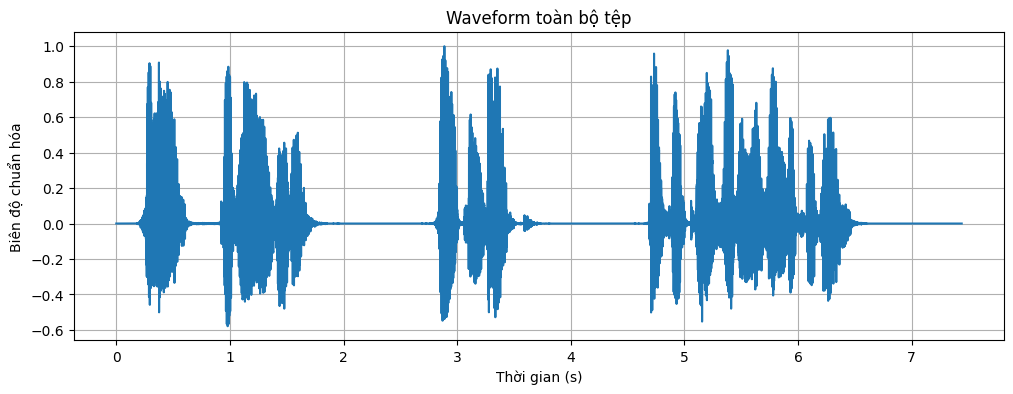

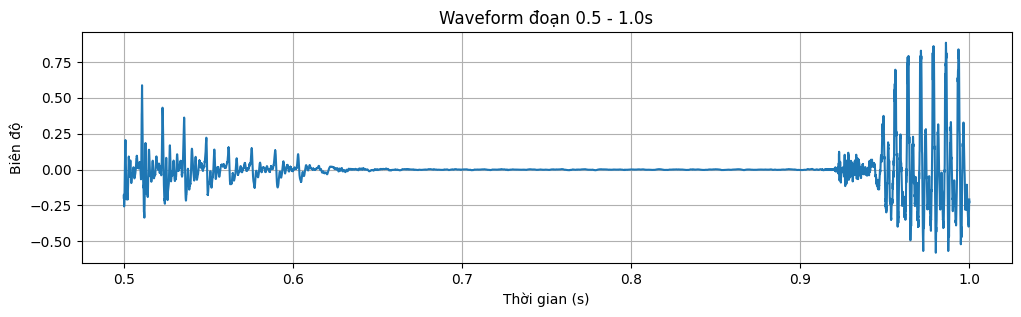

In [12]:
print("\n--- B. PHÂN TÍCH MIỀN THỜI GIAN ---")
peak = np.max(np.abs(x_mono))
rms = np.sqrt(np.mean(x_mono**2))
energy = np.sum(x_mono**2)

print(f"Peak: {peak:.4f}")
print(f"RMS: {rms:.4f} ({20*np.log10(rms):.2f} dBFS)")
print(f"Energy: {energy:.2f}")

# Kiểm tra clipping (nếu peak >= 0.99)
if peak >= 0.99:
    print("CẢNH BÁO: Có thể bị clipping!")
else:
    print("Không phát hiện clipping.")

# Vẽ waveform toàn tệp
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, duration, len(x_mono)), x_mono)
plt.title('Waveform toàn bộ tệp')
plt.xlabel('Thời gian (s)')
plt.ylabel('Biên độ chuẩn hóa')
plt.grid(True)
plt.savefig(f'{FIGURE_DIR}/waveform_full.png')
plt.show()

# Vẽ một đoạn 0.5s
start_sample = int(0.5 * Fs)
end_sample = int(1.0 * Fs)
plt.figure(figsize=(12, 3))
plt.plot(np.linspace(0.5, 1.0, end_sample - start_sample), x_mono[start_sample:end_sample])
plt.title('Waveform đoạn 0.5 - 1.0s')
plt.xlabel('Thời gian (s)')
plt.ylabel('Biên độ')
plt.grid(True)
plt.savefig(f'{FIGURE_DIR}/waveform_segment.png')
plt.show()

C. PHÂN TÍCH MIỀN TẦN SỐ BẰNG FFT


--- C. PHÂN TÍCH FFT ---


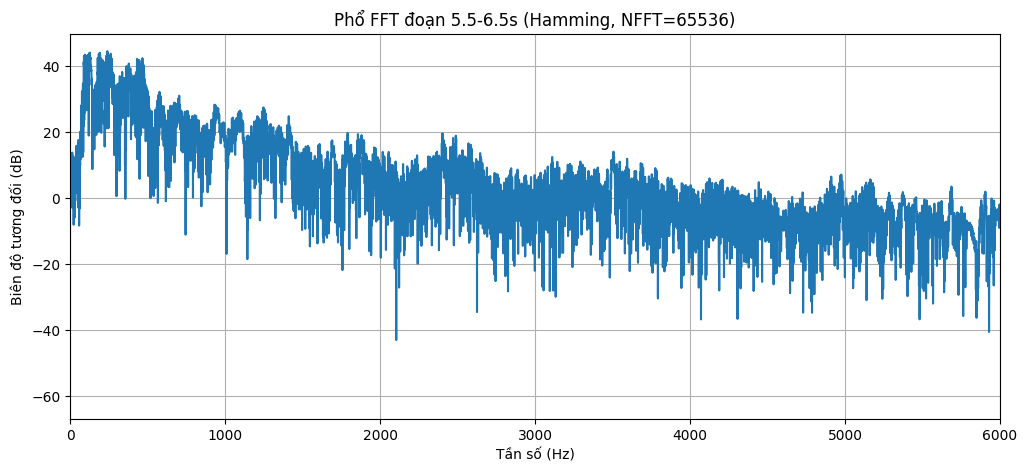

3 đỉnh nổi bật (Hz): [np.float64(240.6005859375), np.float64(127.44140625), np.float64(191.89453125)]
Delta f (NFFT=65536): 0.366 Hz
Delta f (NFFT=2048): 11.719 Hz


In [13]:
print("\n--- C. PHÂN TÍCH FFT ---")
# Chọn đoạn ổn định 1s (ví dụ từ 45s đến 46s như case study)
seg_start = int(5.5 * Fs)
seg_end = int(6.5 * Fs)
seg = x_mono[seg_start:seg_end]

# Nhân cửa sổ Hamming
w = np.hamming(len(seg))
seg_windowed = seg * w

# Tính FFT với NFFT = 65536 (như case study)
NFFT = 65536
X = np.fft.rfft(seg_windowed, n=NFFT)
f = np.fft.rfftfreq(NFFT, 1/Fs)
mag_db = 20 * np.log10(np.maximum(np.abs(X), 1e-12))

# Vẽ phổ
plt.figure(figsize=(12, 5))
plt.plot(f, mag_db)
plt.title('Phổ FFT đoạn 5.5-6.5s (Hamming, NFFT=65536)')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ tương đối (dB)')
plt.xlim(0, 6000) # Giới hạn xem dải tần thấp
plt.grid(True)
plt.savefig(f'{FIGURE_DIR}/fft_spectrum.png')
plt.show()

# Tìm 3 đỉnh nổi bật (đơn giản bằng cách tìm local maxima)
from scipy.signal import find_peaks
peaks, _ = find_peaks(mag_db, height=-40, distance=50) # distance để tránh quá gần nhau
top_peaks = sorted(peaks, key=lambda i: mag_db[i], reverse=True)[:3]
print("3 đỉnh nổi bật (Hz):", [f[i] for i in top_peaks])

# So sánh 2 giá trị NFFT
NFFT_small = 2048
X_small = np.fft.rfft(seg_windowed, n=NFFT_small)
f_small = np.fft.rfftfreq(NFFT_small, 1/Fs)
print(f"Delta f (NFFT=65536): {Fs/NFFT:.3f} Hz")
print(f"Delta f (NFFT=2048): {Fs/NFFT_small:.3f} Hz")

D. STFT VÀ SPECTROGRAM


--- D. STFT VÀ SPECTROGRAM ---


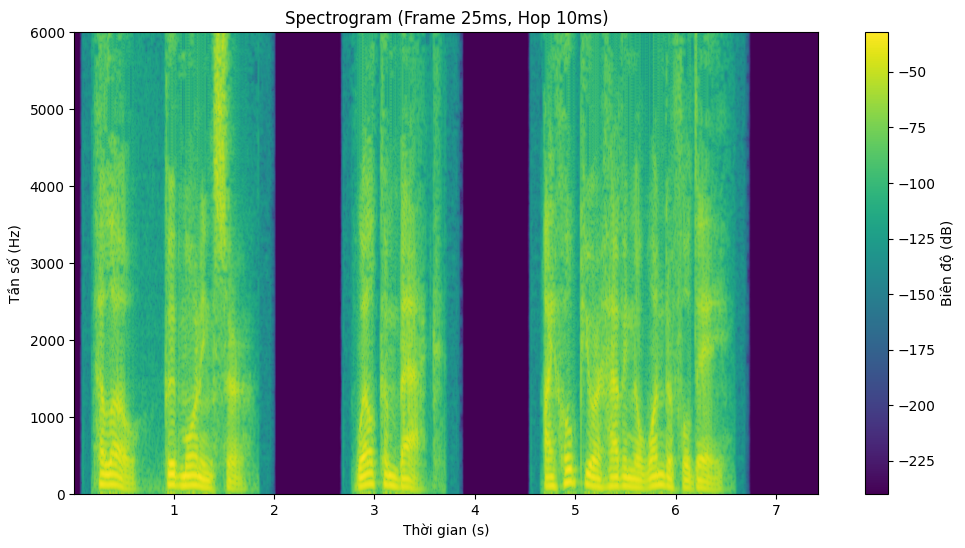

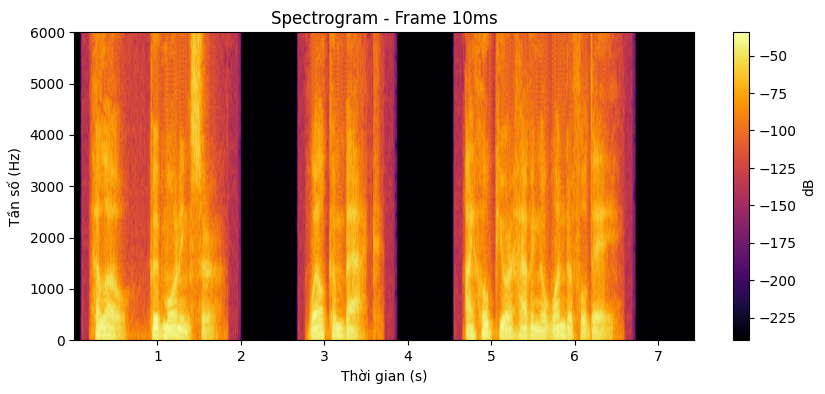

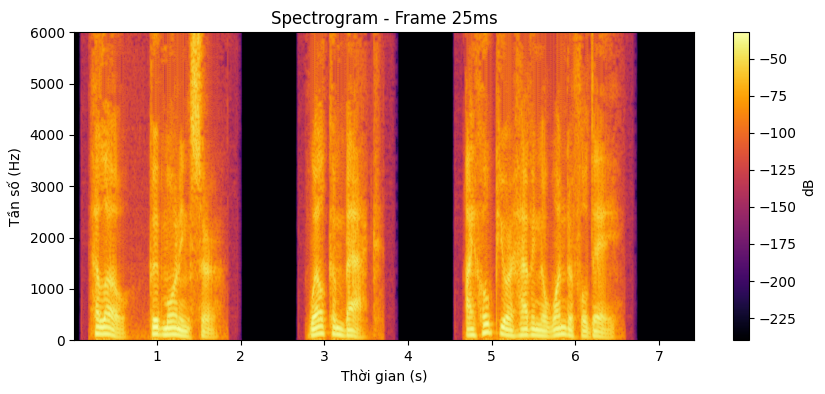

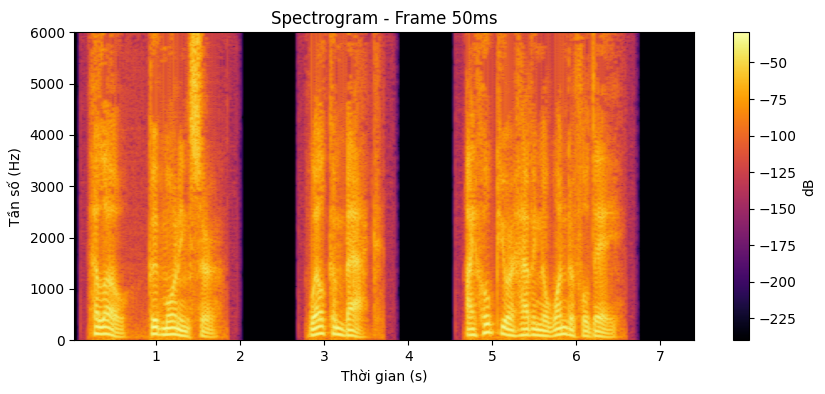

In [14]:
print("\n--- D. STFT VÀ SPECTROGRAM ---")
# Cấu hình chuẩn: frame 25ms, hop 10ms
frame_len = int(0.025 * Fs)
hop_len = int(0.010 * Fs)

# Dùng scipy.signal.spectrogram
f_spec, t_spec, Sxx = signal.spectrogram(x_mono, fs=Fs, window='hamming', 
                                         nperseg=frame_len, noverlap=frame_len-hop_len, 
                                         nfft=2048, mode='magnitude')

# Vẽ spectrogram
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_spec, f_spec, 20*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
plt.title('Spectrogram (Frame 25ms, Hop 10ms)')
plt.ylabel('Tần số (Hz)')
plt.xlabel('Thời gian (s)')
plt.colorbar(label='Biên độ (dB)')
plt.ylim(0, 6000)
plt.savefig(f'{FIGURE_DIR}/spectrogram_25ms.png')
plt.show()

# So sánh 3 frame length: 10ms, 25ms, 50ms
for fl_ms in [10, 25, 50]:
    fl = int(fl_ms / 1000 * Fs)
    hl = int(fl / 2.5) # Giữ tỉ lệ overlap ~60%
    f_tmp, t_tmp, Sxx_tmp = signal.spectrogram(x_mono, fs=Fs, window='hamming', 
                                               nperseg=fl, noverlap=fl-hl, 
                                               nfft=2048, mode='magnitude')
    plt.figure(figsize=(10, 4))
    plt.pcolormesh(t_tmp, f_tmp, 20*np.log10(Sxx_tmp + 1e-12), shading='gouraud', cmap='inferno')
    plt.title(f'Spectrogram - Frame {fl_ms}ms')
    plt.ylabel('Tần số (Hz)')
    plt.xlabel('Thời gian (s)')
    plt.ylim(0, 6000)
    plt.colorbar(label='dB')
    plt.savefig(f'{FIGURE_DIR}/spectrogram_{fl_ms}ms.png')
    plt.show()

E. THÍ NGHIỆM CỬA SỔ


--- E. SO SÁNH CỬA SỔ ---


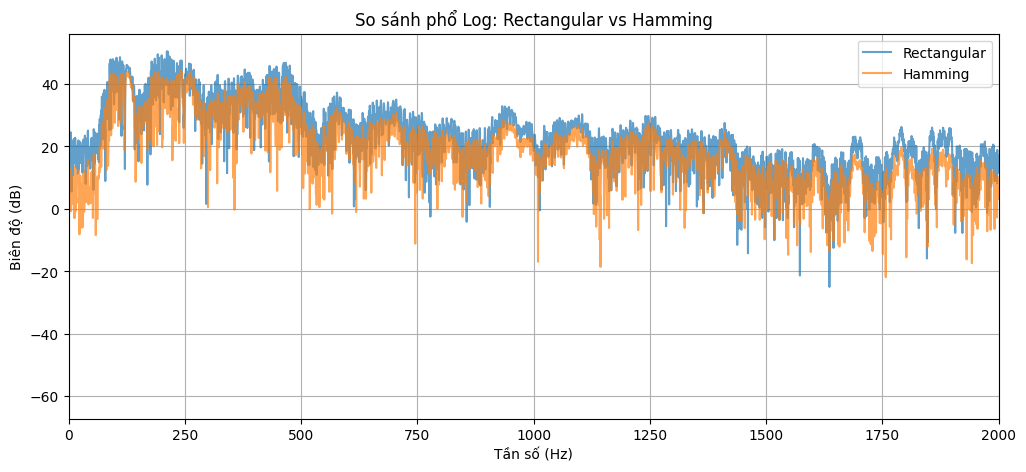

In [15]:
print("\n--- E. SO SÁNH CỬA SỔ ---")
# Dùng cùng một frame dữ liệu (đoạn 5.5-6.5s)
# Rectangular window (không nhân gì cả)
X_rect = np.fft.rfft(seg, n=NFFT)
mag_rect_db = 20 * np.log10(np.maximum(np.abs(X_rect), 1e-12))

# Hamming window (đã tính ở phần C)
plt.figure(figsize=(12, 5))
plt.plot(f, mag_rect_db, label='Rectangular', alpha=0.7)
plt.plot(f, mag_db, label='Hamming', alpha=0.7)
plt.title('So sánh phổ Log: Rectangular vs Hamming')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ (dB)')
plt.xlim(0, 2000) # Zoom vào dải tần thấp để thấy rõ main lobe và side lobe
plt.legend()
plt.grid(True)
plt.savefig(f'{FIGURE_DIR}/window_comparison.png')
plt.show()

F. LỌC SỐ (FIR FILTER)


--- F. LỌC SỐ ---


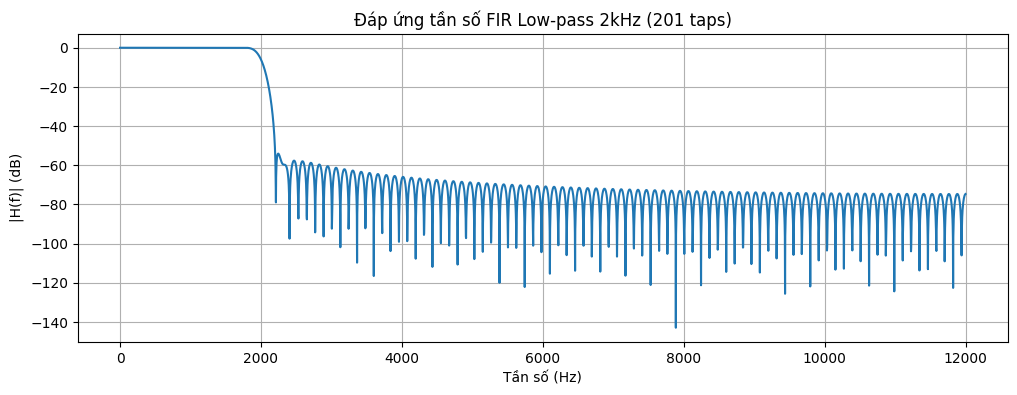

Đã lưu file đã lọc tại audio/filtered_lowpass_2k.wav


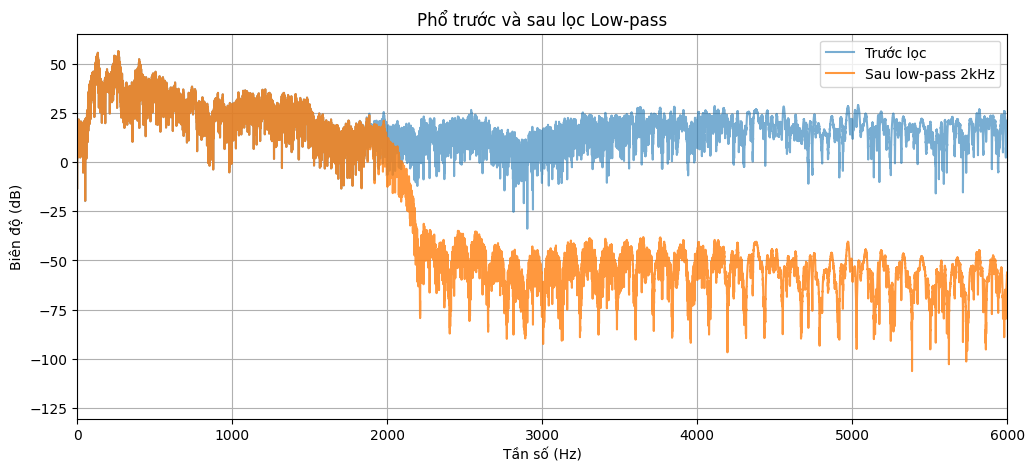

Đã lưu file high-pass tại audio/filtered_highpass_2k.wav


In [16]:
print("\n--- F. LỌC SỐ ---")
# Thiết kế FIR Low-pass 2kHz, 201 taps
numtaps = 201
cutoff = 2000
b_lp = signal.firwin(numtaps, cutoff, fs=Fs, window='hamming')

# Vẽ đáp ứng tần số
w_freq, h_freq = signal.freqz(b_lp, worN=4096, fs=Fs)
plt.figure(figsize=(12, 4))
plt.plot(w_freq, 20*np.log10(np.abs(h_freq)))
plt.title('Đáp ứng tần số FIR Low-pass 2kHz (201 taps)')
plt.xlabel('Tần số (Hz)')
plt.ylabel('|H(f)| (dB)')
plt.grid(True)
plt.savefig(f'{FIGURE_DIR}/filter_response_lp.png')
plt.show()

# Áp dụng lọc
y_lp = signal.lfilter(b_lp, [1.0], x_mono)

# Lưu file nghe thử
sf.write(f'{OUTPUT_DIR}/filtered_lowpass_2k.wav', y_lp, Fs)
print("Đã lưu file đã lọc tại audio/filtered_lowpass_2k.wav")

# So sánh phổ trước và sau lọc (tính FFT của cả tín hiệu gốc và tín hiệu lọc)
X_orig = np.fft.rfft(x_mono, n=NFFT)
X_filtered = np.fft.rfft(y_lp, n=NFFT)
f_full = np.fft.rfftfreq(NFFT, 1/Fs)

plt.figure(figsize=(12, 5))
plt.plot(f_full, 20*np.log10(np.abs(X_orig)+1e-12), label='Trước lọc', alpha=0.6)
plt.plot(f_full, 20*np.log10(np.abs(X_filtered)+1e-12), label='Sau low-pass 2kHz', alpha=0.8)
plt.title('Phổ trước và sau lọc Low-pass')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ (dB)')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True)
plt.savefig(f'{FIGURE_DIR}/spectrum_before_after_filter.png')
plt.show()

# Thiết kế thêm High-pass 2kHz
b_hp = signal.firwin(numtaps, cutoff, fs=Fs, window='hamming', pass_zero=False)
y_hp = signal.lfilter(b_hp, [1.0], x_mono)
sf.write(f'{OUTPUT_DIR}/filtered_highpass_2k.wav', y_hp, Fs)
print("Đã lưu file high-pass tại audio/filtered_highpass_2k.wav")


G. LƯỢNG TỬ HÓA, RESAMPLING VÀ MÃ HÓA

In [17]:
print("\n--- G. LƯỢNG TỬ HÓA & MÃ HÓA ---")
def quantize(x, B):
    qmax = 2**(B-1) - 1
    x_q = np.round(np.clip(x, -1, 1) * qmax) / qmax
    return x_q

def snr_db(x, xq):
    e = xq - x
    return 10 * np.log10(np.sum(x**2) / np.sum(e**2))

bit_depths = [4, 8, 16]
for B in bit_depths:
    x_q = quantize(x_mono, B)
    snr = snr_db(x_mono, x_q)
    print(f"B = {B} bit -> SNR đo được: {snr:.2f} dB")
    if B == 8:
        sf.write(f'{OUTPUT_DIR}/quantized_8bit.wav', x_q, Fs)

# Resampling
for target_sr in [16000, 8000]:
    x_resampled = librosa.resample(x_mono, orig_sr=Fs, target_sr=target_sr)
    sf.write(f'{OUTPUT_DIR}/resampled_{target_sr}Hz.wav', x_resampled, target_sr)
    print(f"Đã resample về {target_sr} Hz")

# Tính bit rate và compression ratio
R_pcm = Fs * 16 * 2 # 44.1kHz, 16bit, stereo
print(f"PCM Bitrate (16-bit stereo): {R_pcm} bit/s = {R_pcm/1000:.1f} kbps")
print(f"MP3 256kbps -> Compression Ratio: {R_pcm / 256000:.2f} : 1")
print(f"MP3 128kbps -> Compression Ratio: {R_pcm / 128000:.2f} : 1")


--- G. LƯỢNG TỬ HÓA & MÃ HÓA ---
B = 4 bit -> SNR đo được: 12.97 dB
B = 8 bit -> SNR đo được: 36.71 dB
B = 16 bit -> SNR đo được: 84.10 dB
Đã resample về 16000 Hz
Đã resample về 8000 Hz
PCM Bitrate (16-bit stereo): 768000 bit/s = 768.0 kbps
MP3 256kbps -> Compression Ratio: 3.00 : 1
MP3 128kbps -> Compression Ratio: 6.00 : 1
